<b><font size="6">OBISITY ML PROJECT</font></b><br><br>

<b style="color: red;">Import Library</font></b><br><br>

In [2]:
#%pip install numpy pandas seaborn scipy scikit-learn

In [46]:
# standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings

# Scipy
from scipy.stats import uniform, randint 

# Sklearn - Feature Selection
from sklearn.feature_selection import mutual_info_classif, RFE

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sklearn - Imputation
from sklearn.impute import KNNImputer, SimpleImputer

# Sklearn - model Selection
from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

# Sklearn - Linear Model 
from sklearn.linear_model import (
    Lasso,
    LinearRegression,
    LogisticRegression
)

# Sklearn - Classification Models 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.naive_bayes import GaussianNB

# Sklearn - Metrics 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer, 
    accuracy_score
)

# Plot settings / Warmning ignoring
sns.set_palette("flare")
warnings.simplefilter(action='ignore', category=FutureWarning)


<a class="anchor" id="">

# Import Data 
</a>

In [4]:
test = pd.read_csv(r"C:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\data\obesity_test.csv")
train = pd.read_csv(r"C:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\data\obesity_train.csv")

<a class="anchor" id="">

# Explore Data 

</a>

In [5]:
train.head()

,id,age,alcohol_freq,caloric_freq,devices_perday,eat_between_meals,gender,height,marrital_status,meals_perday,...,parent_overweight,physical_activity_perweek,region,siblings,smoke,transportation,veggies_freq,water_daily,weight,obese_level
0,1,21.0,Never,no,up to 5,Sometimes,Female,1.62,NaN,3.0,...,yes,NaN,LatAm,3.0,no,Public,Sometimes,1 to 2,64.0,Normal_Weight
1,2,23.0,Frequently,no,up to 5,Sometimes,Male,1.80,NaN,3.0,...,yes,3 to 4,LatAm,0.0,no,Public,Sometimes,1 to 2,77.0,Normal_Weight
2,3,NaN,Frequently,no,up to 2,Sometimes,Male,1.80,NaN,3.0,...,no,3 to 4,LatAm,2.0,no,Walk,Always,1 to 2,87.0,Overweight_Level_I
3,4,22.0,Sometimes,no,up to 2,Sometimes,Male,1.78,NaN,1.0,...,no,NaN,LatAm,3.0,no,Public,Sometimes,1 to 2,90.0,Overweight_Level_II
4,5,22.0,Sometimes,no,up to 2,Sometimes,Male,1.64,NaN,3.0,...,no,5 or more,LatAm,3.0,no,Public,Sometimes,1 to 2,53.0,Normal_Weight


In [6]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1611.0,NaN,NaN,NaN,806.0,465.199957,1.0,403.5,806.0,1208.5,1611.0
age,1545.0,NaN,NaN,NaN,24.344984,6.474498,6.0,20.0,23.0,26.0,88.0
alcohol_freq,1575,4,Sometimes,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
caloric_freq,1591,2,yes,1400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
devices_perday,1589,3,up to 2,708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eat_between_meals,1552,4,Sometimes,1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1591,2,Male,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,1597.0,NaN,NaN,NaN,1.704108,0.095567,1.29,1.63,1.7,1.77,2.19
marrital_status,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meals_perday,1602.0,NaN,NaN,NaN,2.684145,0.817584,1.0,3.0,3.0,3.0,4.0


In [7]:
# The % of missing values in each column

for col in train.columns:
    pct_missing = np.mean(train[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

id - 0%
age - 4%
alcohol_freq - 2%
caloric_freq - 1%
devices_perday - 1%
eat_between_meals - 4%
gender - 1%
height - 1%
marrital_status - 100%
meals_perday - 1%
monitor_calories - 2%
parent_overweight - 1%
physical_activity_perweek - 35%
region - 4%
siblings - 1%
smoke - 1%
transportation - 2%
veggies_freq - 2%
water_daily - 2%
weight - 3%
obese_level - 0%


In [8]:
# The different values for each column to help decide what encoding to use

for col in train.columns:
    print(f"Unique values in '{col}':")
    print(train[col].unique())
    print()

Unique values in 'id':
[   1    2    3 ... 1609 1610 1611]

Unique values in 'age':
[21. 23. nan 22. 24. 41. 27. 52. 20. 19. 39. 30. 25. 29. 26. 38. 18. 17.
 15. 61. 44. 31. 34. 36. 32.  6. 40. 35. 45. 33. 51. 28. 16. 37. 42. 43.
 46. 55. 47. 88.]

Unique values in 'alcohol_freq':
<StringArray>
['Never', 'Frequently', 'Sometimes', 'Always', nan]
Length: 5, dtype: str

Unique values in 'caloric_freq':
<StringArray>
['no', 'yes', nan]
Length: 3, dtype: str

Unique values in 'devices_perday':
<StringArray>
['up to 5', 'up to 2', 'more than 5', nan]
Length: 4, dtype: str

Unique values in 'eat_between_meals':
<StringArray>
['Sometimes', 'Frequently', 'Never', 'Always', nan]
Length: 5, dtype: str

Unique values in 'gender':
<StringArray>
['Female', 'Male', nan]
Length: 3, dtype: str

Unique values in 'height':
[1.62 1.8  1.78 1.64 1.72 1.65 1.93 1.69 1.6  1.85 1.7  1.75 1.68 1.77
 1.79 1.5   nan 1.67 1.66 1.81 1.53 1.82 1.55 1.61 1.76 1.63 1.52 1.56
 1.57 1.58 1.87 1.89 1.74 2.19 1.83 1.92 

In [9]:
print(train.shape)
print(test.shape)

(1611, 21)
(500, 20)


In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1611 entries, 0 to 1610
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         1611 non-null   int64  
 1   age                        1545 non-null   float64
 2   alcohol_freq               1575 non-null   str    
 3   caloric_freq               1591 non-null   str    
 4   devices_perday             1589 non-null   str    
 5   eat_between_meals          1552 non-null   str    
 6   gender                     1591 non-null   str    
 7   height                     1597 non-null   float64
 8   marrital_status            0 non-null      float64
 9   meals_perday               1602 non-null   float64
 10  monitor_calories           1572 non-null   str    
 11  parent_overweight          1591 non-null   str    
 12  physical_activity_perweek  1046 non-null   str    
 13  region                     1544 non-null   str    
 14  sib

In [11]:
# Value counts for each categorical column
cols = [col for col in train.columns if train[col].dtype == 'str']
train[cols] = train[cols].astype('object')

categorical_cols = train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Value counts for {col}:\n{train[col].value_counts()}\n")

Value counts for alcohol_freq:
alcohol_freq
Sometimes     1057
Never          466
Frequently      51
Always           1
Name: count, dtype: int64

Value counts for caloric_freq:
caloric_freq
yes    1400
no      191
Name: count, dtype: int64

Value counts for devices_perday:
devices_perday
up to 2        708
up to 5        696
more than 5    185
Name: count, dtype: int64

Value counts for eat_between_meals:
eat_between_meals
Sometimes     1306
Frequently     170
Never           41
Always          35
Name: count, dtype: int64

Value counts for gender:
gender
Male      826
Female    765
Name: count, dtype: int64

Value counts for monitor_calories:
monitor_calories
no     1501
yes      71
Name: count, dtype: int64

Value counts for parent_overweight:
parent_overweight
yes    1309
no      282
Name: count, dtype: int64

Value counts for physical_activity_perweek:
physical_activity_perweek
1 to 2       595
3 to 4       360
5 or more     91
Name: count, dtype: int64

Value counts for region:
r

In [12]:
# Check to see if we have to deal with any duplication

train.duplicated().sum()

np.int64(0)

### Findings

##### From the exploration I found that:
- Marital_status and Region variables can be dropped as all values are missing.
- Physical_activity_perweek has a very high % of missing values so I will take more care filling them in as this could be an important feature.
- Every other column has minimal missing values.
- We are not dealing with duplicated rows.
- A lot of the columns need to be encoded for use in models.
- A lot of the categorical columns have an option with far higher frequencies.


<a class="anchor" id="">

# Data Visualizations 

</a>

In [13]:
desired_order = ['Insufficient_Weight',
                 'Normal_Weight',
                 'Overweight_Level_I',
                 'Overweight_Level_II',
                 'Obesity_Type_I',
                 'Obesity_Type_II',
                 'Obesity_Type_III']

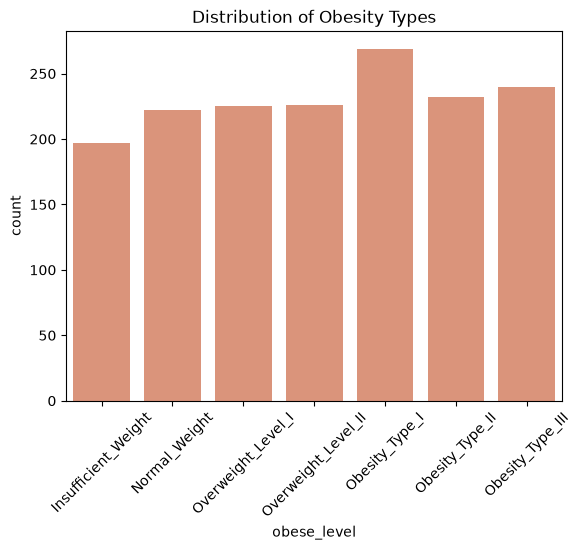

In [14]:
# Indicating how the different obesity types are distributed overall
sns.countplot(data=train, x='obese_level', order=desired_order)
plt.title('Distribution of Obesity Types')
plt.xticks(rotation=45)
plt.show()

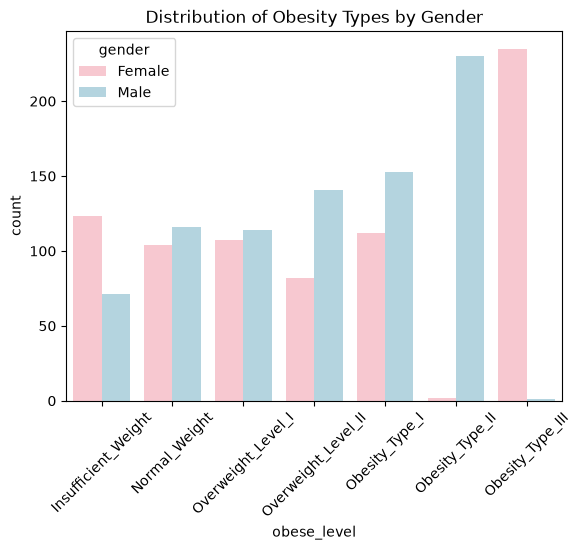

In [15]:
# Distribution of obesity types based on gender 

sns.countplot(data=train, x='obese_level', hue='gender', palette=['pink', 'lightblue'], order=desired_order)
plt.title('Distribution of Obesity Types by Gender')
plt.xticks(rotation=45)
plt.show()

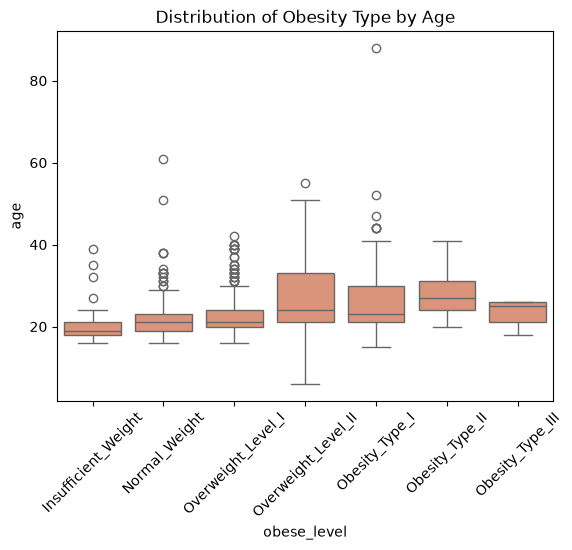

In [16]:
# Distributoion of obesity types based on age 
sns.boxplot(data=train, x='obese_level', y='age', order=desired_order)
plt.title('Distribution of Obesity Type by Age')
plt.xticks(rotation=45)
plt.show()

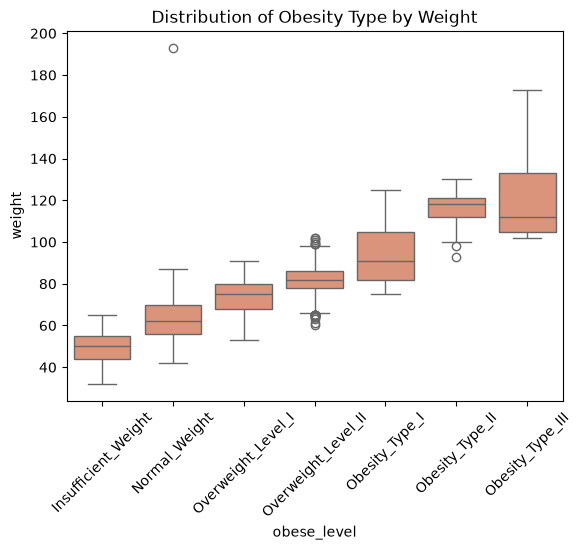

In [17]:
# Ditribution of obesity typed based on weights

sns.boxplot(data=train, x='obese_level', y='weight', order=desired_order)
plt.title('Distribution of Obesity Type by Weight')
plt.xticks(rotation=45)
plt.show()

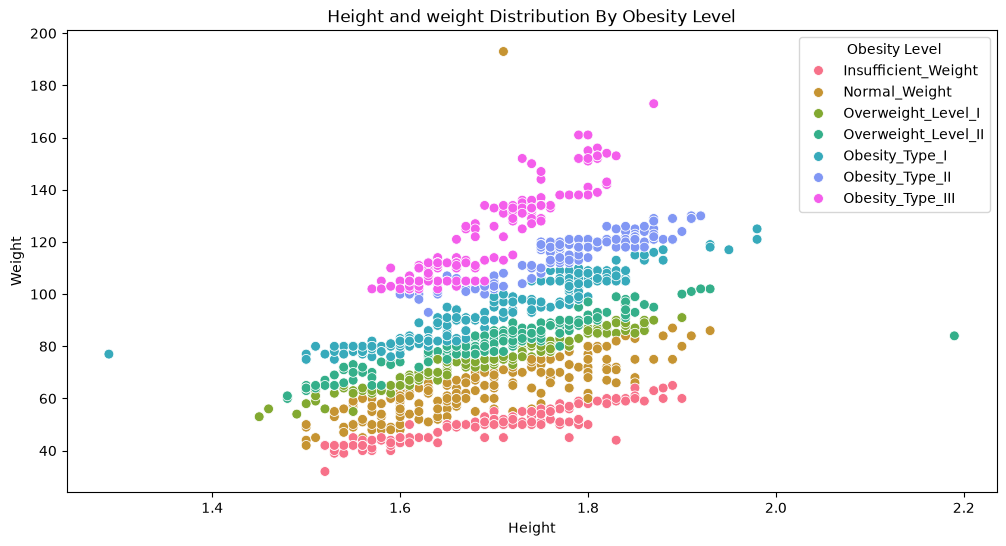

In [18]:
# Shows height and weight distribution by obesity level 

plt.figure(figsize=(12, 6))
sns.scatterplot(data=train, x='height', y='weight', hue='obese_level', s=50, hue_order=desired_order)
plt.title('Height and weight Distribution By Obesity Level')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(title='Obesity Level')
plt.show()

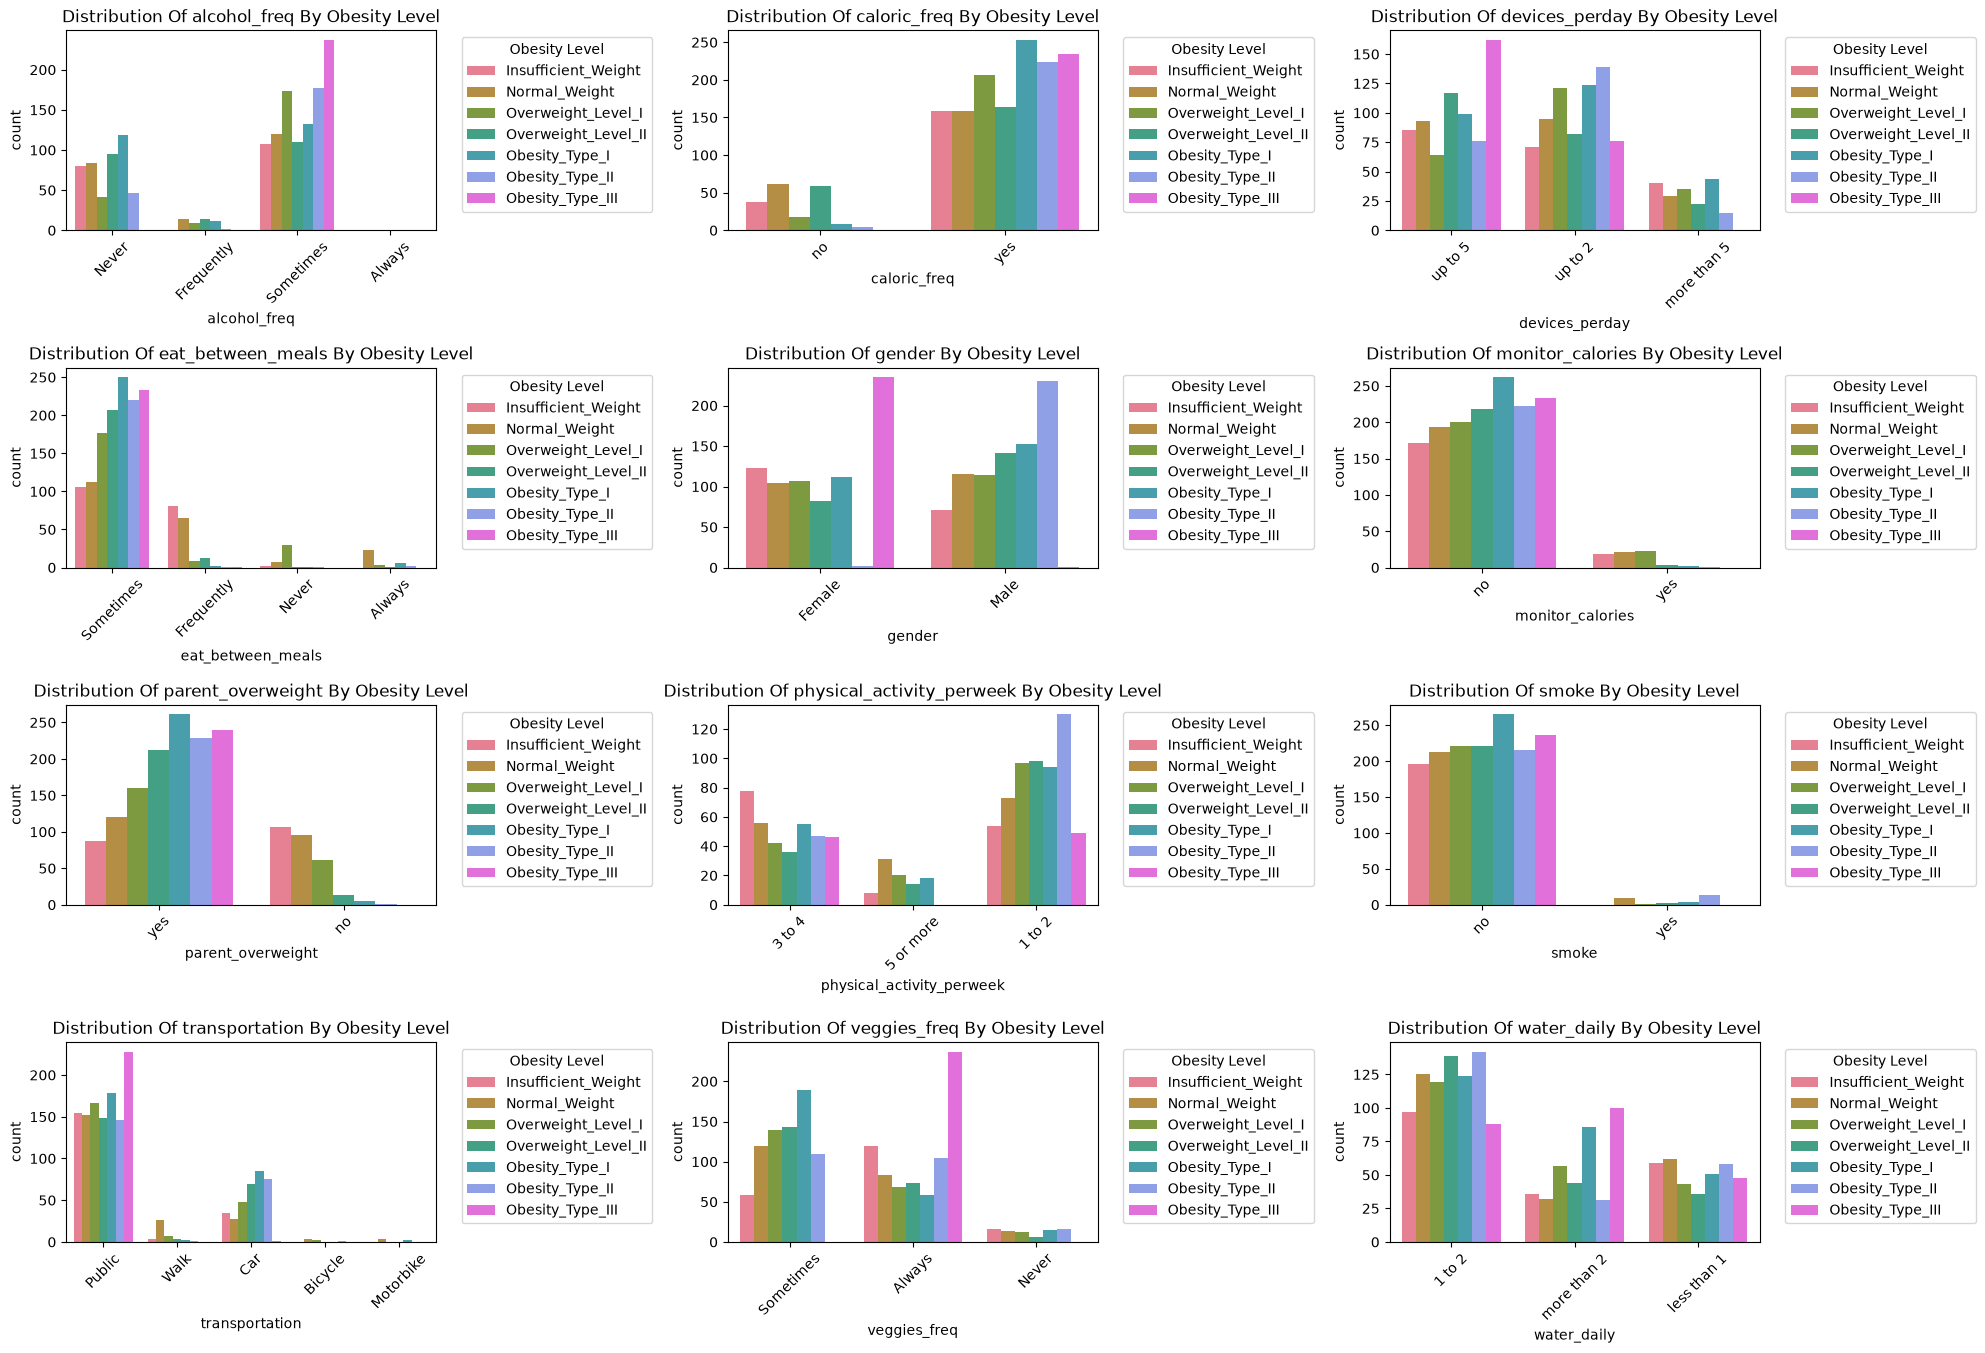

In [19]:
# Shows distribution of all categorical columns againts the different obesity types

categorical_cols = [col for col in train.columns if train[col].dtype == 'object']
categories = [col for col in categorical_cols if col not in ['obese_level', 'region']]

plt.figure(figsize=(20, 16))
for i, var in enumerate(categories, 1):
    plt.subplot(5, 3, i) 
    sns.countplot(data=train, x=var, hue='obese_level', hue_order=desired_order)
    plt.title(f'Distribution Of {var} By Obesity Level')
    plt.xticks(rotation=45)
    plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Findings 

##### From my visualizations I've found that: 

- Obesity type 1 is the most common 
- Gender distribution shows notable differences
- Most of the classes lie between ages 20-40 for all types (could show that age is negligble)
- Height and weight seem to be useful based on the cluters shows 
- We have normal weight, obese level I and II outliers that need to be removed due to logical reasoning
- Higher obesity level shows less physical activity levels
- Some columns showing similar patterns/ little variation showing that they may need to be removed
- I also have an idea on highly correlated features that can be useful later.


<a class="anchor" id="">

# Data Preprocessing 

</a>

In [20]:
# Drop the useless columns and outlier 

train = train.drop(train[train['obese_level'] == 'Normal_Weight']['weight'].idxmax())

train.drop('region', axis=1, inplace=True)  # All the same values
train.drop('marrital_status', axis=1, inplace=True) # All NAN values

In [21]:
# Filling the categorical with missing values before OneHotEcoding 

# Mode imputer
imputer_columns = ['gender', 'transportation','alcohol_freq', 'eat_between_meals']
mode_imputer = SimpleImputer(strategy='most_frequent')
train[imputer_columns] = mode_imputer.fit_transform(train[imputer_columns])

In [22]:
# Ordinal encoding columns where there is a clear progression
train['water_daily'] = train['water_daily'].replace({'less than 1':0, '1 to 2' :1, 'more than 2': 2})
train['physical_activity_perweek'] = train['physical_activity_perweek'].replace({'1 to 2': 0, '3 to 4':1, '5 or more':2})
train['devices_perday'] = train['devices_perday'].replace({'up to 2':0, 'up to 5': 1, 'more than 5': 2})
train['veggies_freq'] = train['veggies_freq'].replace({'Never':0,'Sometimes':1, 'Always':2})

# Converting Yes/ No columns into binary 
binary_cols = ['monitor_calories', 'parent_overweight', 'smoke','caloric_freq']
train[binary_cols] = train[binary_cols].replace({'yes':1, 'no':0})

# Using One Hot Encoding on categorical columns that wouldn't work with ranked ratings 
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform='pandas')
ohetransform = ohe.fit_transform(train[['gender', 'transportation', 'obese_level','alcohol_freq','eat_between_meals']])
train = pd.concat([train, ohetransform], axis=1).drop(columns=['gender', 'transportation', 'obese_level','alcohol_freq','eat_between_meals'])

In [23]:
# checking encoding worked as expected
train.head(10)

,id,age,caloric_freq,devices_perday,height,meals_perday,monitor_calories,parent_overweight,physical_activity_perweek,siblings,...,obese_level_Overweight_Level_I,obese_level_Overweight_Level_II,alcohol_freq_Always,alcohol_freq_Frequently,alcohol_freq_Never,alcohol_freq_Sometimes,eat_between_meals_Always,eat_between_meals_Frequently,eat_between_meals_Never,eat_between_meals_Sometimes
0,1,21.0,0,1,1.62,3.0,0,1,NaN,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,2,23.0,0,1,1.80,3.0,0,1,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,NaN,0,0,1.80,3.0,0,0,1,2.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,22.0,0,0,1.78,1.0,0,0,NaN,3.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,5,22.0,0,0,1.64,3.0,0,0,2,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5,6,24.0,1,1,1.78,3.0,0,1,0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,7,21.0,1,1,1.72,3.0,1,1,1,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7,8,22.0,0,0,1.65,3.0,0,0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8,9,41.0,1,1,1.80,3.0,0,0,1,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9,10,27.0,1,0,1.93,1.0,0,1,0,2.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [24]:
# Filling in missing values on the rest of the encoded columns

#KNN imputer
columns_to_impute = train.columns
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
train[columns_to_impute] = knn_imputer.fit_transform(train[columns_to_impute])

In [25]:
# Showing all the new columns and that there are no missing values
train.isnull().sum()

id                                 0
age                                0
caloric_freq                       0
devices_perday                     0
height                             0
meals_perday                       0
monitor_calories                   0
parent_overweight                  0
physical_activity_perweek          0
siblings                           0
smoke                              0
veggies_freq                       0
water_daily                        0
weight                             0
gender_Female                      0
gender_Male                        0
transportation_Bicycle             0
transportation_Car                 0
transportation_Motorbike           0
transportation_Public              0
transportation_Walk                0
obese_level_Insufficient_Weight    0
obese_level_Normal_Weight          0
obese_level_Obesity_Type_I         0
obese_level_Obesity_Type_II        0
obese_level_Obesity_Type_III       0
obese_level_Overweight_Level_I     0
o

<a class="anchor" id="">

# Feature Engineering

</a>

In [26]:
# Calculate BMI and add a new columns in the dataset as the BMI is a good prediction of obesity

train['bmi'] = train['weight'] / (train['height']**2)

In [27]:
# Create classification columns based on bmi scores and scientific studies found online 
# Source: https://www.ncbi.nlm.nih.gov/books/NBK541070/

train['underweight'] = (train['bmi'] < 18.5).astype(int)
train['normal_weight'] = ((train['bmi'] >= 18.5) & (train['bmi'] <= 24.9)).astype(int)
train['overweight'] = ((train['bmi'] >= 25) & (train['bmi'] <= 29.9)).astype(int)
train['obese'] = (train['bmi'] >= 30).astype(int)
train['obesity_class_I'] = ((train['bmi'] >= 30) & (train['bmi'] <=34.9)).astype(int)
train['obesity_class_II'] = ((train['bmi'] >= 35) & (train['bmi'] <=39.9)).astype(int)
train['obesity_class_III'] = (train['bmi'] >= 40).astype(int)

In [28]:
train.columns # Check all columns

Index(['id', 'age', 'caloric_freq', 'devices_perday', 'height', 'meals_perday',
       'monitor_calories', 'parent_overweight', 'physical_activity_perweek',
       'siblings', 'smoke', 'veggies_freq', 'water_daily', 'weight',
       'gender_Female', 'gender_Male', 'transportation_Bicycle',
       'transportation_Car', 'transportation_Motorbike',
       'transportation_Public', 'transportation_Walk',
       'obese_level_Insufficient_Weight', 'obese_level_Normal_Weight',
       'obese_level_Obesity_Type_I', 'obese_level_Obesity_Type_II',
       'obese_level_Obesity_Type_III', 'obese_level_Overweight_Level_I',
       'obese_level_Overweight_Level_II', 'alcohol_freq_Always',
       'alcohol_freq_Frequently', 'alcohol_freq_Never',
       'alcohol_freq_Sometimes', 'eat_between_meals_Always',
       'eat_between_meals_Frequently', 'eat_between_meals_Never',
       'eat_between_meals_Sometimes', 'bmi', 'underweight', 'normal_weight',
       'overweight', 'obese', 'obesity_class_I', 'obesity_cl

<a class="anchor" id="">

# Model selection

</a>

In [29]:
# Establish a plethora of models to find the best performing ones for our data

model_1 = LogisticRegression(max_iter=100000)
model_2 = KNeighborsClassifier()
model_3 = SVC()
model_4 = DecisionTreeClassifier()
model_5 = RandomForestClassifier()
model_6 = GaussianNB()
model_7 = GradientBoostingClassifier()

In [30]:
# Select feature based on correlation, and specify the target variables so we can do a test train split

features = ['age', 'caloric_freq', 'devices_perday', 'height', 'meals_perday',
       'monitor_calories', 'parent_overweight', 'physical_activity_perweek',
       'siblings', 'smoke', 'veggies_freq', 'water_daily', 'weight',
       'gender_Female', 'gender_Male',
       'transportation_Car', 'transportation_Motorbike',
       'transportation_Public', 'transportation_Walk',
       'alcohol_freq_Frequently', 'alcohol_freq_Never',
       'alcohol_freq_Sometimes', 'eat_between_meals_Always',
       'eat_between_meals_Frequently', 'eat_between_meals_Never',
       'eat_between_meals_Sometimes', 'bmi', 'underweight', 'normal_weight',
       'overweight', 'obese', 'obesity_class_I', 'obesity_class_II',
       'obesity_class_III']

target = ['obese_level_Insufficient_Weight', 'obese_level_Normal_Weight',
    'obese_level_Obesity_Type_I', 'obese_level_Obesity_Type_II',
    'obese_level_Obesity_Type_III', 'obese_level_Overweight_Level_I',
    'obese_level_Overweight_Level_II']

X = train[features]
y = train[target].idxmax(axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True, stratify=y)

In [31]:
model_1.fit(X_train, y_train)

c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 13988 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",100000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use

In [32]:
model_2.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](7,)","['obese_level_Insufficient_Weight','obese_level_Normal_Weight', 'obese_level_Obesity_Type_I',...,'obese_level_Obesity_Type_III', 'obese_level_Overweight_Level_I','obese_level_Overweight_Level_II']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [33]:
model_3.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [34]:
model_4.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [35]:
model_5.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
model_6.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](7,)","[148.,166.,201.,...,180.,169.,169.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](7,)","[0.12,0.14,0.17,...,0.15,0.14,0.14]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U31](7,)","['obese_level_Insufficient_Weight','obese_level_Normal_Weight', 'obese_level_Obesity_Type_I',...,'obese_level_Obesity_Type_III', 'obese_level_Overweight_Level_I','obese_level_Overweight_Level_II']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.753e-07
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['age','caloric_freq','devices_perday',...,'obesity_class_I', 'obesity_class_II','obesity_class_III']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](7, 34)","[[19.9 , 0.81, 0.86,..., 0. , 0. , 0. ], [21.72, 0.72, 0.69,..., 0.01, 0. , 0. ], [25.83, 0.96, 0.74,..., 0.96, 0.02, 0. ], ..., [23.52, 0.99, 0.71,..., 0. , 0.19, 0.79], [23.28, 0.9 , 0.59,..., 0. , 0. , 0. ], [26.3 , 0.73, 0.69,..., 0.02, 0. , 0. ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](7, 34)","[[ 7.13, 0.15, 0.52,..., 0. , 0. , 0. ], [24.99, 0.2 , 0.5 ,..., 0.01, 0. , 0. ], [56.47, 0.03, 0.54,..., 0.04, 0.02, 0. ], ..., [ 7.27, 0.01, 0.21,..., 0. , 0.16, 0.16], [31.17, 0.09, 0.57,..., 0. , 0. , 0. ], [55.22, 0.2 , 0.39,..., 0.02, 0. , 0. ]]"


In [37]:
model_7.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [38]:
models = [model_1, model_2, model_3, model_4, model_5, model_6, model_7]

models_names = ['LogisticRegression', 'KNeighborsClassifier', 'SVC', 'DecisionTreeClassifier', 'RandomForestClassifier','GaussianNB', 'GradientBoostingClassifier']

In [39]:
# Compare modlels
accuracy_results = {}

for model, name in zip(models, models_names):
    y_pred = model.predict(X_test)

    accuracy = f1_score(y_test, y_pred, average='macro')
    accuracy_results[name] = accuracy

sorted_accuracy_results = sorted(accuracy_results.items(), key= lambda x: x[1], reverse=True)

print('Model Accuracy Comparison:')
for model_name, accuracy in sorted_accuracy_results:
    print(f'{model_name} : {accuracy: .4f}')

Model Accuracy Comparison:
LogisticRegression :  0.9595
RandomForestClassifier :  0.9542
GradientBoostingClassifier :  0.9517
DecisionTreeClassifier :  0.9330
KNeighborsClassifier :  0.9286
GaussianNB :  0.7545
SVC :  0.7199


##### Findings
- I found the RandomForesClassifier, GradientBoostingClassifier, and LogisticRegression to be the most accuracy models for our data, so we will use them in our ensable model.

<a class="anchor" id="">

# Feature Selection

</a>

In [40]:
# Recursive feature elimination to find desirable fearures

rfe = RFE(estimator= model, n_features_to_select=30)
rfe.fit(X_train, y_train)

selected_fearures = X_train.columns[rfe.support_]
print('Top 30 features:\n', selected_fearures)

Top 30 features:
 Index(['age', 'caloric_freq', 'devices_perday', 'height', 'meals_perday',
       'monitor_calories', 'parent_overweight', 'physical_activity_perweek',
       'siblings', 'smoke', 'veggies_freq', 'water_daily', 'weight',
       'gender_Female', 'gender_Male', 'transportation_Car',
       'transportation_Public', 'transportation_Walk', 'alcohol_freq_Never',
       'alcohol_freq_Sometimes', 'eat_between_meals_Always',
       'eat_between_meals_Frequently', 'eat_between_meals_Sometimes', 'bmi',
       'underweight', 'normal_weight', 'overweight', 'obese',
       'obesity_class_I', 'obesity_class_II'],
      dtype='str')


In [41]:
# Mutal class information to find correlated features

mi = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({"Feature": X_train.columns, "Mutual Information": mi})

mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

print(mi_df.head(20))

                         Feature  Mutual Information
26                           bmi            1.745451
12                        weight            1.144982
30                         obese            0.673618
29                    overweight            0.523434
28                 normal_weight            0.353304
31               obesity_class_I            0.347535
27                   underweight            0.326017
32              obesity_class_II            0.310920
0                            age            0.306856
33             obesity_class_III            0.276857
3                         height            0.233965
14                   gender_Male            0.190964
13                 gender_Female            0.164919
10                  veggies_freq            0.155456
6              parent_overweight            0.147753
4                   meals_perday            0.129605
23  eat_between_meals_Frequently            0.123273
25   eat_between_meals_Sometimes            0.

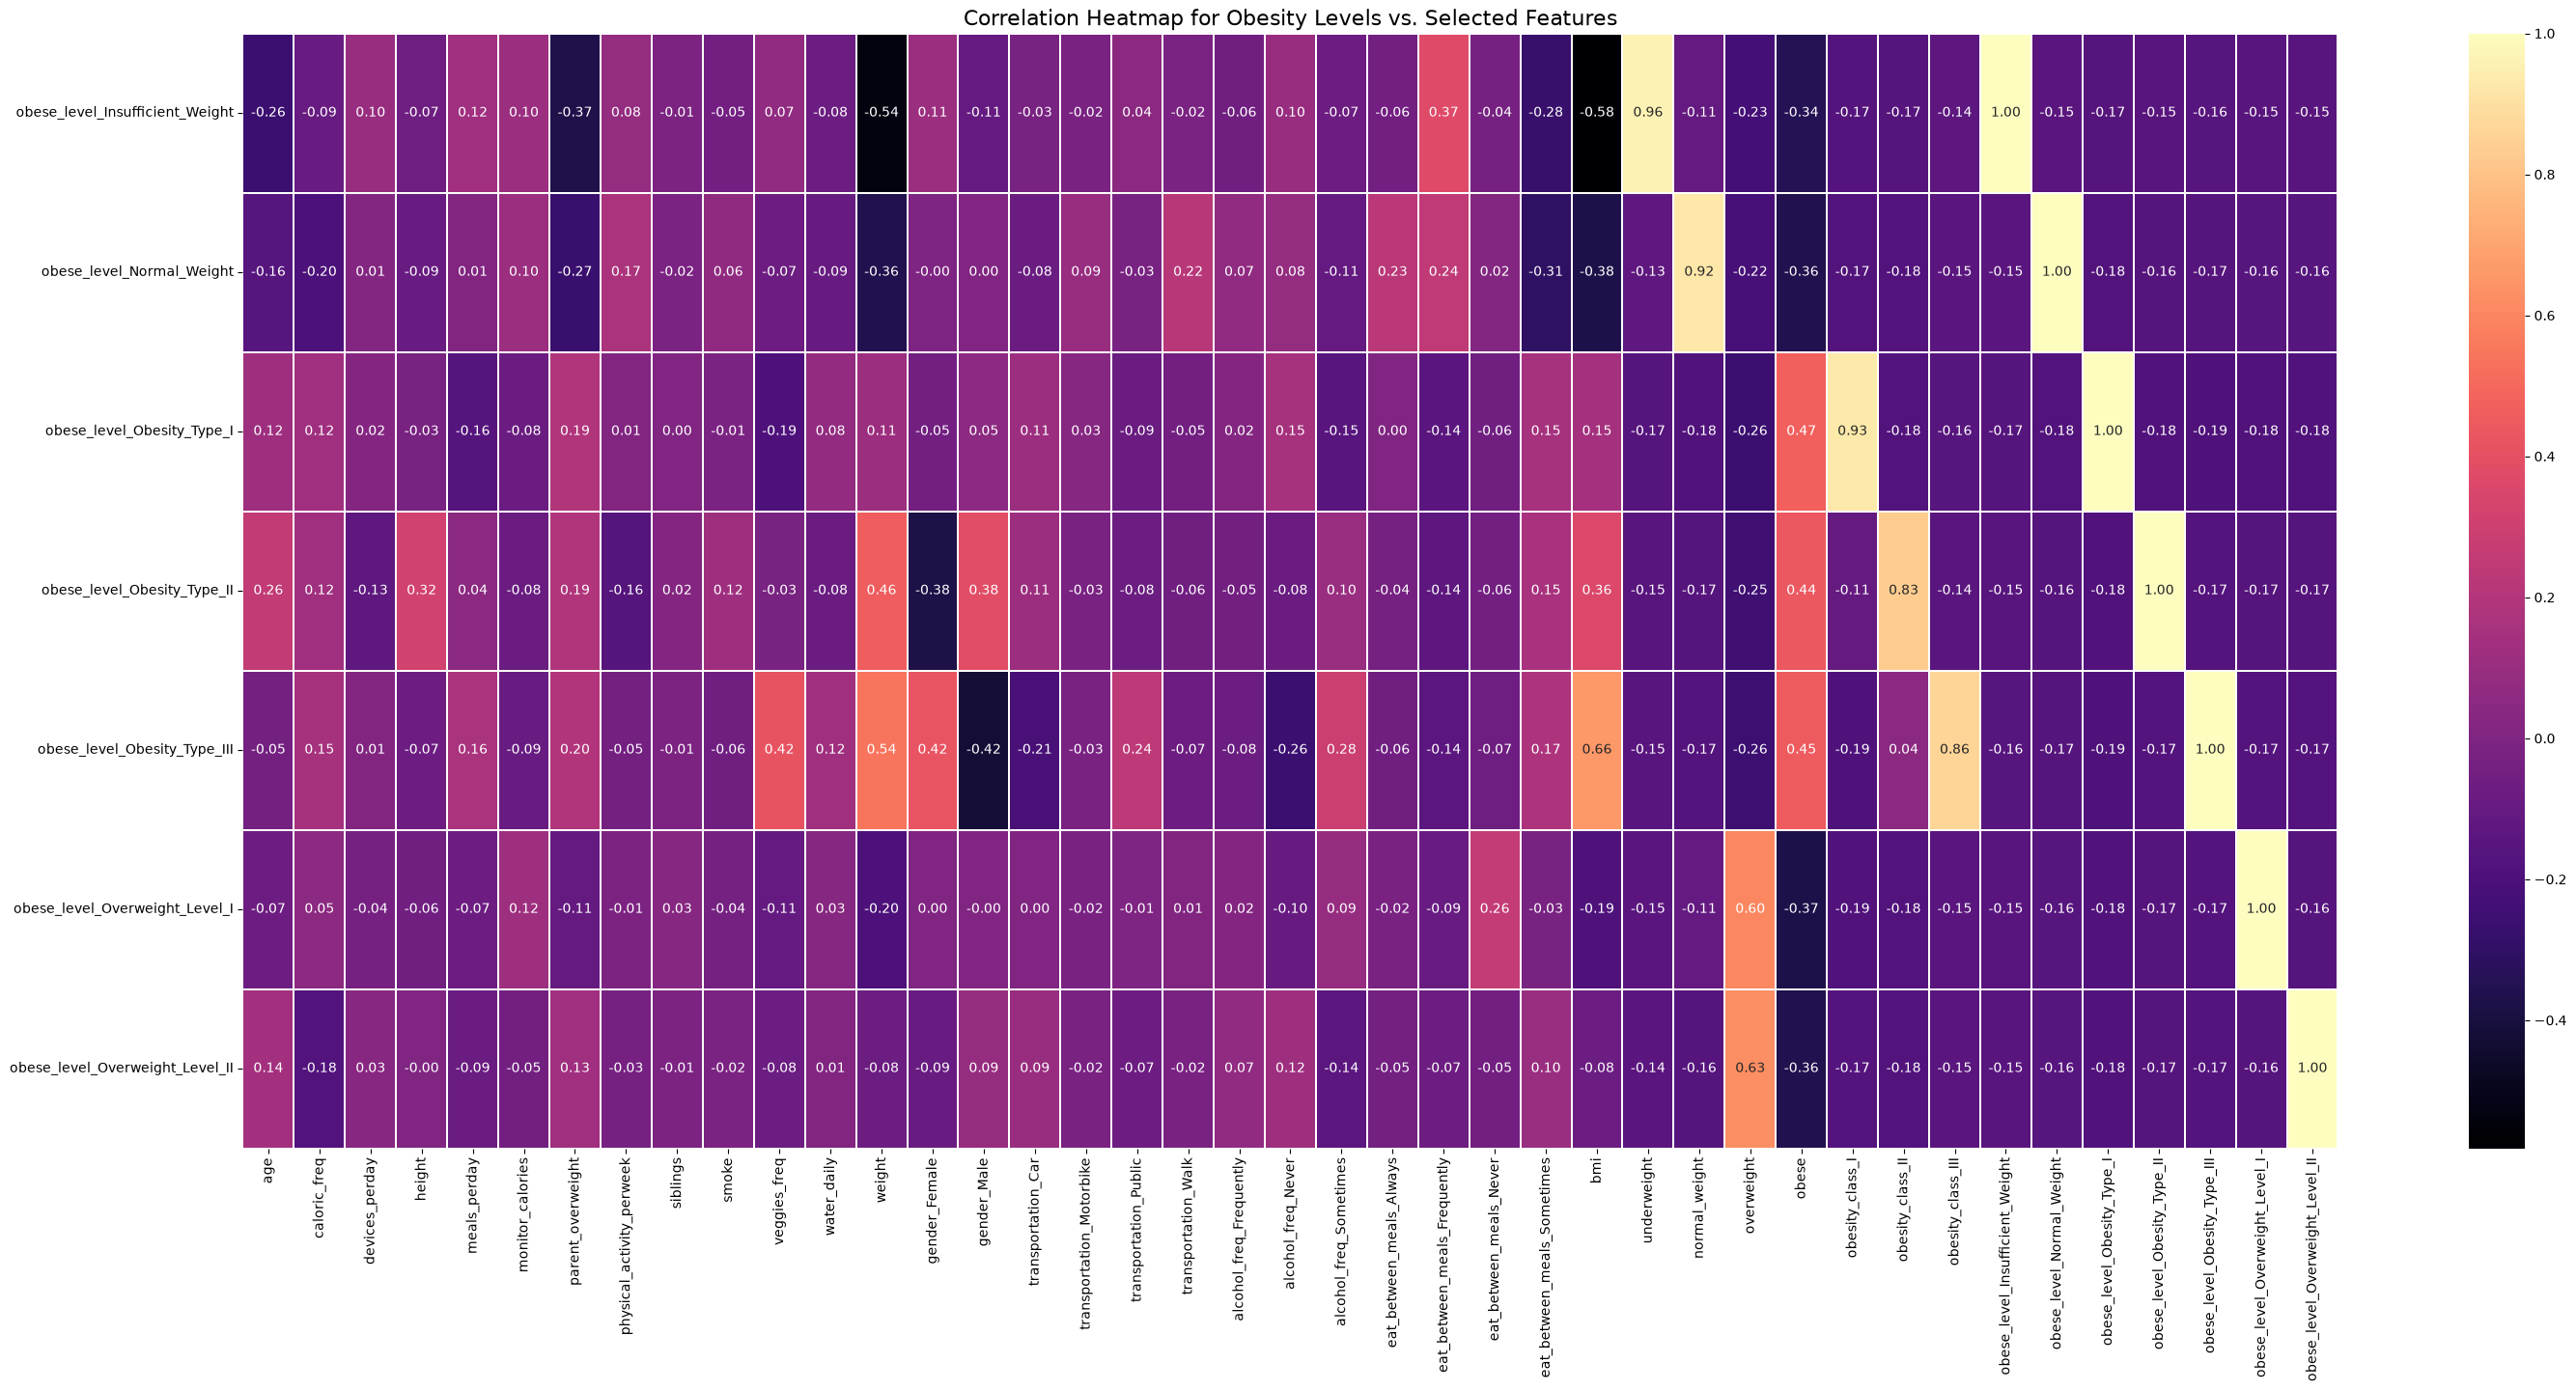

In [42]:
# Correlation matrix 

all_columns = features + target

correlation_matrix = train[all_columns].corr()

filtered_corr_matrix = correlation_matrix.loc[:, target].T

plt.figure(figsize=(35,15))
sns.heatmap(filtered_corr_matrix, annot=True, cmap='magma', fmt='.2f', linewidths=0.2, annot_kws={'size':10})
plt.title('Correlation Heatmap for Obesity Levels vs. Selected Features', fontsize=16)
plt.show()

<a class="anchor" id="">

# Model Tuning 

</a>

In [44]:
# Random search into grid search for the gradient boosting classifier

model = GradientBoostingClassifier()
param_distributions = {
    'n_estimators' : randint(25,150),
    'max_depth': randint(5,15),
    'min_samples_split': randint(2,10),
    'min_samples_leaf': randint(1,5),
    'learning_rate': uniform(0.01, 0.2),
    'subsample' : uniform(0.7, 0.3),
    }

random_search = RandomizedSearchCV(
    model,
    param_distributions= param_distributions,
    n_iter= 50,
    cv=3,
    verbose=2,
    n_jobs= -1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params_random = random_search.best_params_
print("Best parameters from RandomizedSearchCV;", best_params_random)
print("Best cross-validation score: {:.4f}".format(random_search.best_score_))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters from RandomizedSearchCV; {'learning_rate': np.float64(0.20475110376829186), 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 140, 'subsample': np.float64(0.8777243706586126)}
Best cross-validation score: 0.9635


In [47]:
# Define a narrower parameter grid around the best parameters

param_grid = {
    'n_estimators' : [best_params_random['n_estimators'] - 10,
                      best_params_random['n_estimators'],
                       [best_params_random['n_estimators'] + 10]],

        'max_depth': [best_params_random['max_depth'] - 1,
                      best_params_random['max_depth'],
                       [best_params_random['max_depth'] + 1]],

        'min_samples_split': [best_params_random['min_samples_split'],
                                best_params_random['min_samples_split'] + 1],


        'min_samples_leaf': [best_params_random['min_samples_leaf'] - 1, 
                         best_params_random['min_samples_leaf'], 
                         best_params_random['min_samples_leaf'] + 1],


        'learning_rate': [best_params_random['learning_rate'] * 0.8, 
                      best_params_random['learning_rate'], 
                      best_params_random['learning_rate'] * 1.2],


        'subsample' : [max(0.7, best_params_random['subsample'] - 0.1), 
                  best_params_random['subsample'], 
                  min(1.0, best_params_random['subsample'] + 0.1)], 
}

# Set up GridSearchCV with the narrowed parameter grid
grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

y_pred = grid_search.best_estimator_.predict(X_test)
print('Test set accuracy: {:.4f}'.format(accuracy_score(y_test, y_pred)))

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
1350 fits failed out of a total of 2430.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
540 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~

Best parameters from GridSearchCV: {'learning_rate': np.float64(0.20475110376829186), 'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 140, 'subsample': np.float64(0.7777243706586127)}
Best cross-validation score: 0.9652
Test set accuracy: 0.9504


In [48]:
# Establish fit the model with the best hyperparameters based on the searches

gbmodel = GradientBoostingClassifier(
    random_state=42,
    learning_rate=0.2,
    max_depth=6,
    min_samples_leaf=4,
    min_samples_split=8,
    n_estimators=140,
    subsample=0.7,
    max_features='log2'
)

gbmodel.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",140
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: {'sqrt', 'log2'}, int or float, default=NoneThe number of features to consider when looking for the best split:- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0]` and the features considered at each split will be `max(1, int(max_features * n_features_in_))`.- If 'sqrt', then `max_features=sqrt(n_features)`.- If 'log2', then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Choosing `max_features < n_features` leads to a reduction of varianceand an increase in bias.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'fried

In [53]:
# Do the same for the RandomForestClassifier

model = RandomForestClassifier(random_state=42)

param_distributions = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf' : randint(1, 5),
    'max_features' : ['sqrt', 'log2', None],
    'bootstrap':[True, False]
    }

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    model, 
    param_distributions= param_distributions,
    n_iter=50,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params_random = random_search.best_params_
print('Best parameters from RandomizedSearchCV:', best_params_random)
print('Best cross-validation score: {:.4f}'.format(random_search.best_score_))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters from RandomizedSearchCV: {'bootstrap': False, 'max_depth': 13, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 133}
Best cross-validation score: 0.9685


In [57]:
# define a narrower parameter grid around th best parameters

param_grid = {
    'n_estimators' : [best_params_random['n_estimators'] - 50,
                         best_params_random['n_estimators'],
                           [best_params_random['n_estimators'] + 50]],
    
            'max_depth': [best_params_random['max_depth'] - 2,
                          best_params_random['max_depth'],
                           [best_params_random['max_depth'] + 2]],
    
            'min_samples_split': [best_params_random['min_samples_split'],
                                    best_params_random['min_samples_split'] + 1],
    
    
            'min_samples_leaf': [best_params_random['min_samples_leaf'], 
                             best_params_random['min_samples_leaf']+1, 
                             best_params_random['min_samples_leaf'] + 1],
    
            'max_features' : [best_params_random['max_features']],  # keep it fixed for fine-tuning
            'bootstrap' : [best_params_random['bootstrap']]    #  keep it fixed for fine-tuning
            }

grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,   # 5-fold cross-validation
    verbose=2,    # display progress
    n_jobs=-1   # use all CPU cores
)

grid_search.fit(X_train, y_train)

print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

# Predict with the best model and print results
y_pred = grid_search.best_estimator_.predict(X_test)
print("Test set accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters from GridSearchCV: {'bootstrap': False, 'max_depth': 13, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 133}
Best cross-validation score: 0.9635
Test set accuracy: 0.9628


c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
150 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~

In [58]:
# Establish and fit the model with the best hyperparameters based on the searches

rfmodel = RandomForestClassifier(
    bootstrap=False,
    max_depth=13,
    max_features='log2',
    min_samples_leaf=1,
    min_samples_split=3,
    n_estimators=133
)

rfmodel.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",133
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",13
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [62]:
# Do the same for Logistic Regression

model = LogisticRegression(solver='lbfgs', max_iter=1000)

param_distributions = {
    'C': uniform(0.001, 10),
    'penalty': ['l1','l2'],
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=3, 
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

best_params_random = random_search.best_params_
print(f'Best parameter from RandomizedSearchCV: {best_params_random}')
print(f'Best cross-validation score: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
54 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
 

Best parameter from RandomizedSearchCV: {'C': np.float64(0.34488521115218396), 'penalty': 'l2'}
Best cross-validation score: 0.9287


c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [63]:
param_grid = {
    'C' :[best_params_random['C']*0.5, best_params_random['C'], best_params_random['C']*2],
    'penalty' : [best_params_random['penalty']]
}

grid_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

best_params_grid = grid_search.best_params_
print(f"Best parameters from GridSearch: {best_params_grid}")
print(f'Best cross-validation score: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters from GridSearch: {'C': np.float64(0.17244260557609198), 'penalty': 'l2'}
Best cross-validation score: 0.9304


c:\Users\nhatp\OneDrive - NOVAIMS\gits\Machine_learning_1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [64]:
lrmodel = LogisticRegression(
    C=0.17244260557609198,
    penalty='l2',
    solver='lbfgs',
    max_iter=10000
)

lrmodel.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.17244260557609198
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm

<a class="anchor" id="">

# Final Model Implementation And Testing

</a>

In [67]:
# Establish and fit a voting model to combine the three models
# Using weights skewed towards the random forest as it proved to be the best for performance 

voting_model = VotingClassifier(
    estimators= [('rf', rfmodel),
                 ('gb', gbmodel),
                 ('lr', lrmodel)],
                 voting='soft',
                 weights=[2,1,1], 
                 n_jobs=-1
)

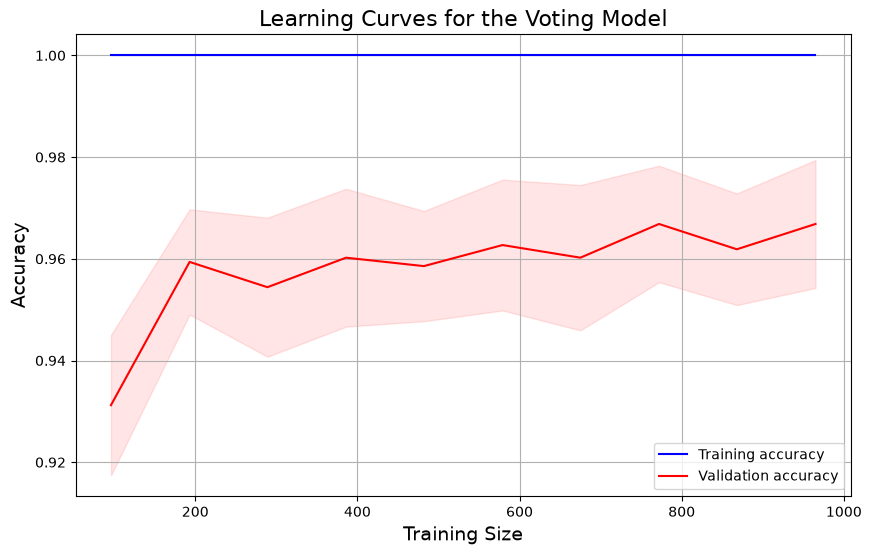

In [69]:
# Learing curve used to see over/ underfitting and variance of our predictions

train_sizes, train_scores, val_scores = learning_curve(voting_model,
    X_train, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training accuracy')
plt.plot(train_sizes, val_mean, color='red', label='Validation accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, color='red', alpha=0.1)

plt.title('Learning Curves for the Voting Model', fontsize=16)
plt.xlabel('Training Size', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [70]:
# Fit our final model and show the macro f1 scores as it is the same scoring systems used in the competition
# Also show the classification report to give us better insights on prediction performance for specific labels

voting_model.fit(X_train, y_train)

y_pred = voting_model.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(F"Macro F1 Score: {macro_f1}")
print(classification_report(y_test, y_pred))

Macro F1 Score: 0.9618090803355166
                                 precision    recall  f1-score   support

obese_level_Insufficient_Weight       0.96      0.96      0.96        49
      obese_level_Normal_Weight       0.91      0.93      0.92        55
     obese_level_Obesity_Type_I       0.97      0.99      0.98        68
    obese_level_Obesity_Type_II       0.98      0.98      0.98        58
   obese_level_Obesity_Type_III       0.98      0.98      0.98        60
 obese_level_Overweight_Level_I       0.96      0.93      0.95        56
obese_level_Overweight_Level_II       0.96      0.96      0.96        57

                       accuracy                           0.96       403
                      macro avg       0.96      0.96      0.96       403
                   weighted avg       0.96      0.96      0.96       403



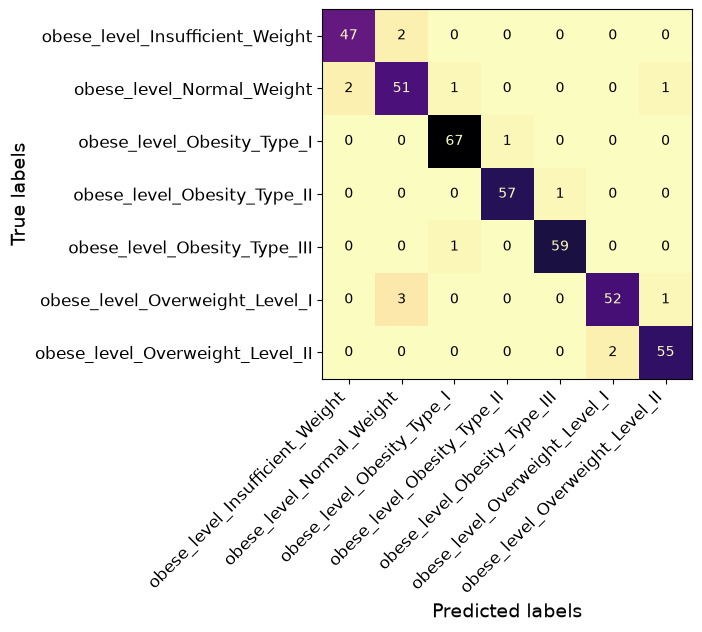

<Figure size 1000x600 with 0 Axes>

In [71]:
# Use a Confusion Matrix Display to show where model is making incorrect prediction and where the errors are ending up
# Seeing that having issues in predicting the normal weight

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, cmap='magma_r')
plt.xlabel('Predicted labels', fontsize=14)
plt.ylabel('True labels', fontsize=14)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12)
plt.figure(figsize=(10,6))

plt.tight_layout()
plt.show()